In [1]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
from torch.utils.data import DataLoader, TensorDataset

def load_and_preprocess_cicids2017_strict(dataset_dir='./dataset/', sample_frac=1.0, is_binary_classification=False):
    print(f"[*] 开始加载 CIC-IDS2017 数据集 (严格三切分模式)...")
    
    all_files = glob.glob(os.path.join(dataset_dir, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"未找到 CSV 文件，请检查 {dataset_dir} 路径！")
    
    df_list = []
    for file in all_files:
        print(f"    -> 正在加载: {os.path.basename(file)}")
        df_chunk = pd.read_csv(file, low_memory=False, encoding='cp1252')
        if sample_frac < 1.0:
            df_chunk = df_chunk.sample(frac=sample_frac, random_state=42)
        df_list.append(df_chunk)
        
    df = pd.concat(df_list, ignore_index=True)
    df.columns = df.columns.str.strip()
    
    # 鲁棒性清洗
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
    cols_to_drop = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

    # 标签处理
    if is_binary_classification:
        df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
        y = df['Label'].values
    else:
        encoder = LabelEncoder()
        y = encoder.fit_transform(df['Label'])
        print(f"    -> 类别映射: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")
        
    X = df.drop(columns=['Label'])

    # Z-Score 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ==========================================
    # 核心修改：严格三切分 (80:10:10)
    # ==========================================
    # 1. 抽 10% 作为期末考试 (Test)
    X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42, stratify=y)
    
    # 2. 从剩下的 90% 中抽 10% (约等于整体的 10%) 作为模拟考 (Validation)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
    
    num_features = X_train.shape[1]
    
    # 转 3D 张量
    X_train_reshaped = np.reshape(X_train, (X_train.shape[0], num_features, 1))
    X_val_reshaped = np.reshape(X_val, (X_val.shape[0], num_features, 1))
    X_test_reshaped = np.reshape(X_test, (X_test.shape[0], num_features, 1))
    
    print(f"[*] 数据划分完成！特征数: {num_features}")
    print(f"    -> 训练集: {X_train_reshaped.shape}")
    print(f"    -> 验证集: {X_val_reshaped.shape}")
    print(f"    -> 测试集: {X_test_reshaped.shape}")
    
    return X_train_reshaped, X_val_reshaped, X_test_reshaped, y_train, y_val, y_test, num_features



In [6]:
# 执行数据处理 (建议先用 sample_frac=0.1 测试通畅后再用 1.0 全量跑)
X_train, X_val, X_test, y_train, y_val, y_test, num_features = load_and_preprocess_cicids2017_strict(
    sample_frac=1.0, is_binary_classification=False
)

# 生成 DataLoader
batch_size = 512
def create_loader(X, y, shuffle=False):
    return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), 
                                    torch.tensor(y, dtype=torch.long)), 
                      batch_size=batch_size, shuffle=shuffle)

train_loader = create_loader(X_train, y_train, shuffle=True)
val_loader = create_loader(X_val, y_val, shuffle=False)
test_loader = create_loader(X_test, y_test, shuffle=False)

[*] 开始加载 CIC-IDS2017 数据集 (严格三切分模式)...
    -> 正在加载: Friday-WorkingHours-Morning.pcap_ISCX.csv
    -> 正在加载: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    -> 正在加载: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    -> 正在加载: Tuesday-WorkingHours.pcap_ISCX.csv
    -> 正在加载: Monday-WorkingHours.pcap_ISCX.csv
    -> 正在加载: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    -> 正在加载: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    -> 正在加载: Wednesday-workingHours.pcap_ISCX.csv
    -> 类别映射: {'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack – Brute Force': np.int64(12), 'Web Attack – Sql Injection': np.int64(13), 'Web Attack – XSS': np.int64(14), nan: np.int64(15)}
[*] 数据划分完成！特征数: 78


In [7]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, features):
        attn_scores = self.attention(features) 
        attn_weights = F.softmax(attn_scores, dim=1) 
        context_vector = torch.sum(attn_weights * features, dim=1) 
        return context_vector, attn_weights

class Universal_IDS_Model(nn.Module):
    # (与之前代码完全相同，万能模型架构)
    def __init__(self, num_features, num_classes=15, use_cnn=False, rnn_type='LSTM', bidirectional=False, use_attention=False):
        super(Universal_IDS_Model, self).__init__()
        self.use_cnn = use_cnn; self.rnn_type = rnn_type; self.use_attention = use_attention
        
        if self.use_cnn:
            self.cnn = nn.Sequential(
                nn.Conv1d(1, 64, 3, 1, 1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
            )
            rnn_input_size = 64; self.cnn_output_len = num_features // 2
        else:
            rnn_input_size = 1
            
        rnn_hidden_size = 64
        self.num_directions = 2 if bidirectional else 1
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(rnn_input_size, rnn_hidden_size, 2, batch_first=True, bidirectional=bidirectional)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(rnn_input_size, rnn_hidden_size, 2, batch_first=True, bidirectional=bidirectional)
        else:
            self.rnn = None
            
        if self.use_attention:
            attn_input_dim = rnn_hidden_size * self.num_directions if rnn_type else 64
            self.attention = Attention(attn_input_dim)
            classifier_input_dim = attn_input_dim
        else:
            if rnn_type: classifier_input_dim = rnn_hidden_size * self.num_directions
            else: classifier_input_dim = 64 * self.cnn_output_len
                
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_dim, 64), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        if self.use_cnn:
            x = x.transpose(1, 2)
            x = self.cnn(x)
            x = x.transpose(1, 2)
        if self.rnn_type: x, _ = self.rnn(x)
        if self.use_attention: x, _ = self.attention(x)
        else:
            if self.rnn_type: x = x[:, -1, :]
            else: x = x.contiguous().view(x.size(0), -1)
        return self.classifier(x)



In [10]:
import copy
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim

def train_and_validate_with_history(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 用来记录每个 Epoch 各项指标的字典
    history = {
        'train_loss': [], 'val_loss': [], 
        'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []
    }
    
    best_val_f1 = 0.0
    best_model_weights = None
    
    for epoch in range(epochs):
        # --- 训练阶段 ---
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            
        train_loss /= len(train_loader.dataset)
        history['train_loss'].append(train_loss)
            
        # --- 验证阶段 ---
        model.eval()
        val_loss = 0.0
        all_labels, all_preds = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                
                loss = criterion(outputs, labels.long())
                val_loss += loss.item() * inputs.size(0)
                
                _, predicted = torch.max(outputs.data, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        
        # --- 计算所有验证集评估指标 ---
        val_acc = accuracy_score(all_labels, all_preds)
        val_prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        val_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        
        history['val_acc'].append(val_acc)
        history['val_prec'].append(val_prec)
        history['val_rec'].append(val_rec)
        history['val_f1'].append(val_f1)
        
        # ==========================================
        # 💡 补回来的打印代码在这里！实时监控训练状态
        # ==========================================
        print(f"  └─ Epoch [{epoch+1:02d}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        
        # 在验证集上寻找最优权重深拷贝保存下来
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_weights = copy.deepcopy(model.state_dict())
            
    # 循环结束，把模型恢复到表现最好时的状态
    model.load_state_dict(best_model_weights)
    
    return model, best_val_f1, history

[*] 所有生成的图片和表格将自动保存在文件夹: ./ablation_results/ 中

[===== 开始寻优：训练12个模型并生成图表 =====]

[*] 正在训练: LSTM ...
  └─ Epoch [01/25] | Train Loss: 0.2389 | Val Loss: 0.1053 | Val Acc: 0.9602 | Val F1: 0.9601
  └─ Epoch [02/25] | Train Loss: 0.1481 | Val Loss: 0.0875 | Val Acc: 0.9668 | Val F1: 0.9659
  └─ Epoch [03/25] | Train Loss: 0.1034 | Val Loss: 0.1234 | Val Acc: 0.9535 | Val F1: 0.9513
  └─ Epoch [04/25] | Train Loss: 0.0931 | Val Loss: 0.0780 | Val Acc: 0.9634 | Val F1: 0.9633
  └─ Epoch [05/25] | Train Loss: 0.0777 | Val Loss: 0.0738 | Val Acc: 0.9699 | Val F1: 0.9694
  └─ Epoch [06/25] | Train Loss: 0.0709 | Val Loss: 0.0737 | Val Acc: 0.9733 | Val F1: 0.9724
  └─ Epoch [07/25] | Train Loss: 0.0687 | Val Loss: 0.0632 | Val Acc: 0.9735 | Val F1: 0.9727
  └─ Epoch [08/25] | Train Loss: 0.0682 | Val Loss: 0.0695 | Val Acc: 0.9723 | Val F1: 0.9718
  └─ Epoch [09/25] | Train Loss: 0.0630 | Val Loss: 0.0628 | Val Acc: 0.9750 | Val F1: 0.9744
  └─ Epoch [10/25] | Train Loss: 0.0617 | Val Loss: 0.

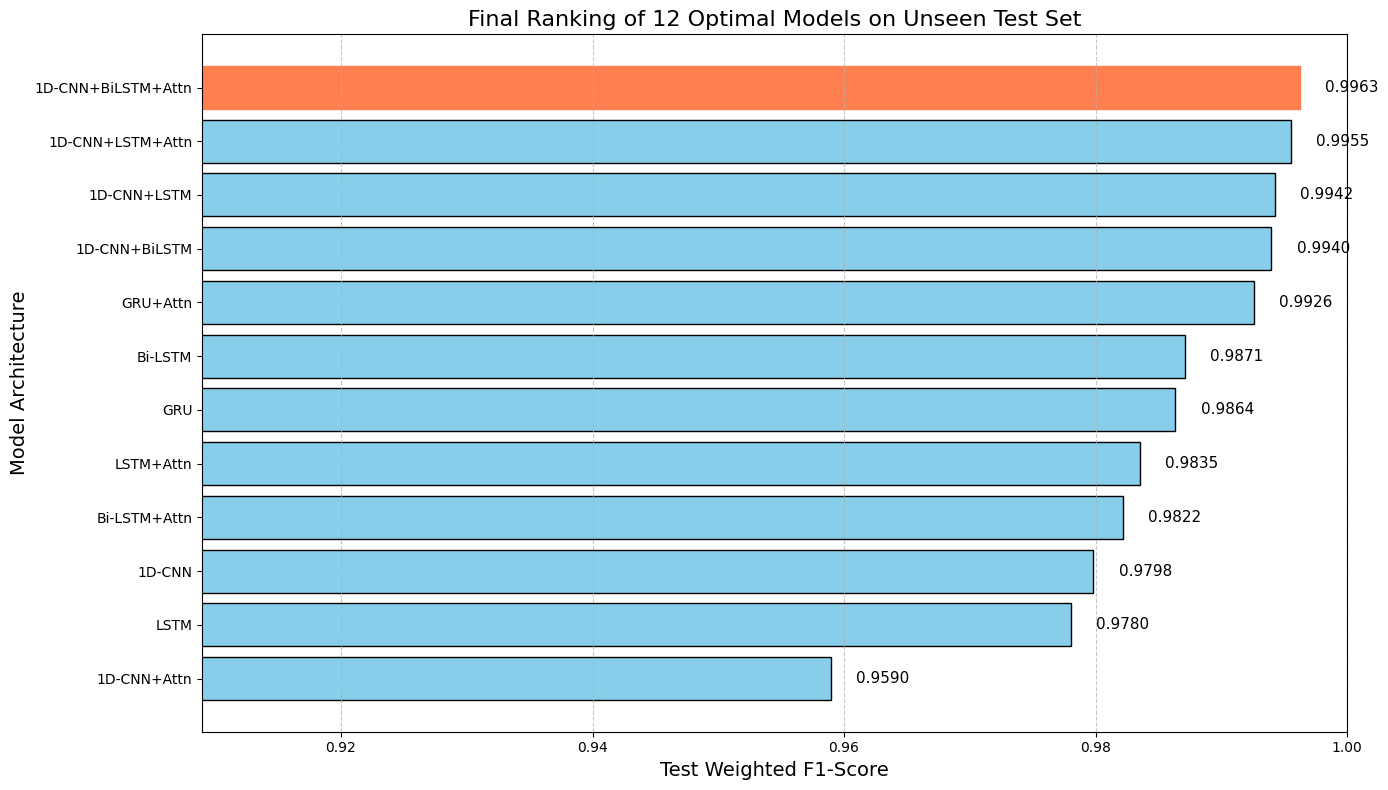


[大功告成] 所有 26 个结果文件均已妥善保存在 ./ablation_results/ 目录中！去打开看看吧！


In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

# ==========================================
# 0. 自动创建结果保存文件夹
# ==========================================
SAVE_DIR = "ablation_results" # 你可以把这里改成你想叫的文件夹名字
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"[*] 所有生成的图片和表格将自动保存在文件夹: ./{SAVE_DIR}/ 中")

# ==========================================
# 1. 绘图辅助函数 (折线图 & 混淆矩阵)
# ==========================================
def plot_learning_curves(history, model_name):
    """绘制并保存当前模型的训练折线图"""
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))
    
    # 【左图】：Train Loss vs Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='x')
    plt.title(f'Loss Curve: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 【右图】：四大评估指标走势
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], label='Accuracy', marker='s')
    plt.plot(epochs_range, history['val_prec'], label='Precision', marker='^')
    plt.plot(epochs_range, history['val_rec'], label='Recall', marker='v')
    plt.plot(epochs_range, history['val_f1'], label='F1-Score', marker='d')
    plt.title(f'Metrics on Validation Set: {model_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.ylim(0.0, 1.05) 
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    safe_name = model_name.replace("+", "_")
    
    # 重点修改：把图片保存进新建的文件夹
    save_path = os.path.join(SAVE_DIR, f'{safe_name}_learning_curves.png')
    plt.savefig(save_path, dpi=300)
    plt.close() # 画完就关闭画布，防止内存飙升

def plot_and_save_confusion_matrix(y_true, y_pred, model_name):
    """绘制并保存当前模型在测试集上的混淆矩阵"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Test Confusion Matrix: {model_name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    
    safe_name = model_name.replace("+", "_")
    save_path = os.path.join(SAVE_DIR, f'{safe_name}_confusion_matrix.png')
    plt.savefig(save_path, dpi=300)
    plt.close()

# ==========================================
# 2. 开始主线大比拼
# ==========================================
num_unique_classes = len(np.unique(y_train))
ABLATION_EPOCHS = 25 # 记得正式跑的时候可以调大

ablation_configs = {
    "LSTM":           {"use_cnn": False, "rnn_type": 'LSTM', "bidirectional": False, "use_attention": False},
    "LSTM+Attn":      {"use_cnn": False, "rnn_type": 'LSTM', "bidirectional": False, "use_attention": True},
    "Bi-LSTM":        {"use_cnn": False, "rnn_type": 'LSTM', "bidirectional": True,  "use_attention": False},
    "Bi-LSTM+Attn":   {"use_cnn": False, "rnn_type": 'LSTM', "bidirectional": True,  "use_attention": True},
    "GRU":            {"use_cnn": False, "rnn_type": 'GRU',  "bidirectional": False, "use_attention": False},
    "GRU+Attn":       {"use_cnn": False, "rnn_type": 'GRU',  "bidirectional": False, "use_attention": True},
    "1D-CNN":         {"use_cnn": True,  "rnn_type": None,   "bidirectional": False, "use_attention": False},
    "1D-CNN+Attn":    {"use_cnn": True,  "rnn_type": None,   "bidirectional": False, "use_attention": True},
    "1D-CNN+LSTM":           {"use_cnn": True, "rnn_type": 'LSTM', "bidirectional": False, "use_attention": False},
    "1D-CNN+LSTM+Attn":      {"use_cnn": True, "rnn_type": 'LSTM', "bidirectional": False, "use_attention": True},
    "1D-CNN+BiLSTM":         {"use_cnn": True, "rnn_type": 'LSTM', "bidirectional": True,  "use_attention": False},
    "1D-CNN+BiLSTM+Attn":    {"use_cnn": True, "rnn_type": 'LSTM', "bidirectional": True,  "use_attention": True}
}

results_log = []

print("\n[===== 开始寻优：训练12个模型并生成图表 =====]")

for model_name, config in ablation_configs.items():
    print(f"\n[*] 正在训练: {model_name} ...")
    model = Universal_IDS_Model(num_features, num_unique_classes, **config)
    
    # 训练并在验证集上找最优
    optimal_model, best_val_f1, history = train_and_validate_with_history(
        model, train_loader, val_loader, epochs=ABLATION_EPOCHS
    )
    
    # 画折线图并存入文件夹
    plot_learning_curves(history, model_name)
    
    # 用最优形态挑战终极测试集 (Test Set)
    optimal_model.eval()
    test_labels, test_preds = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = optimal_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            test_labels.extend(labels.cpu().numpy())
            test_preds.extend(predicted.cpu().numpy())
            
    # 计算测试集得分
    test_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
    test_acc = accuracy_score(test_labels, test_preds)
    
    print(f"    -> 测试集 F1: {test_f1:.4f}")
    
    # 画混淆矩阵并存入文件夹
    plot_and_save_confusion_matrix(test_labels, test_preds, model_name)
    
    results_log.append({
        "Model Architecture": model_name,
        "Validation F1": best_val_f1,
        "Test Accuracy": test_acc,
        "Test F1-Score": test_f1
    })

# ==========================================
# 3. 生成最终琅琊榜与对比柱状图
# ==========================================
df_results = pd.DataFrame(results_log)
df_sorted = df_results.sort_values(by="Test F1-Score", ascending=False).reset_index(drop=True)

print("\n[===== 🏆 最终琅琊榜：12大模型真实战斗力排名 🏆 =====]")
print(df_sorted.to_string())

# 把表格保存进文件夹
csv_path = os.path.join(SAVE_DIR, "all_models_final_ranking.csv")
df_sorted.to_csv(csv_path, index=False)
print(f"[*] 成绩单已保存至: {csv_path}")

# 画最终大排行柱状图
plt.figure(figsize=(14, 8))
df_plot = df_sorted.sort_values(by="Test F1-Score", ascending=True)
bars = plt.barh(df_plot["Model Architecture"], df_plot["Test F1-Score"], color='skyblue', edgecolor='black')

for i, bar in enumerate(bars):
    if df_plot.iloc[i]["Model Architecture"] == "1D-CNN+BiLSTM+Attn":
        bar.set_color('coral')

plt.title('Final Ranking of 12 Optimal Models on Unseen Test Set', fontsize=16)
plt.xlabel('Test Weighted F1-Score', fontsize=14)
plt.ylabel('Model Architecture', fontsize=14)
min_f1 = df_plot["Test F1-Score"].min() - 0.05
plt.xlim(max(0, min_f1), 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', fontsize=11)

plt.tight_layout()

# 把排行榜图片也保存进文件夹
leaderboard_path = os.path.join(SAVE_DIR, 'models_ranking_leaderboard.png')
plt.savefig(leaderboard_path, dpi=300)
plt.show() # 最后一张总榜图直接在 Notebook 页面里展示一下

print(f"\n[大功告成] 所有 26 个结果文件均已妥善保存在 ./{SAVE_DIR}/ 目录中！去打开看看吧！")

In [12]:
import os
import torch

# 因为 1D-CNN+BiLSTM+Attn 是循环的最后一项，内存中的 optimal_model 刚好就是它！
model_save_path = os.path.join("ablation_results", '1D_CNN_BiLSTM_Attn_best.pth')

# 直接保存当前内存里的模型权重
torch.save(optimal_model.state_dict(), model_save_path)

print(f"🎉 冠军模型已成功保存至: {model_save_path}")

🎉 冠军模型已成功保存至: ablation_results/1D_CNN_BiLSTM_Attn_best.pth
